In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [16]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(PROCESSED_DIR / "nhaven_higher_ed_clean.csv")

print(df.shape)
df.head()

(24, 9)


,unit_id,institution,year,grad_rate_4yr,grad_rate_6yr,enroll_pt,enroll_ft,retention_ft,retention_pt
0,130226,Quinnipiac University,2023,77,80,178,6070,87,0.0
1,130226,Quinnipiac University,2021,65,69,313,5985,87,NaN
2,130226,Quinnipiac University,2019,71,75,302,6543,84,0.0
3,130226,Quinnipiac University,2017,71,76,346,6959,86,17.0
4,130226,Quinnipiac University,2015,72,76,279,6703,87,100.0


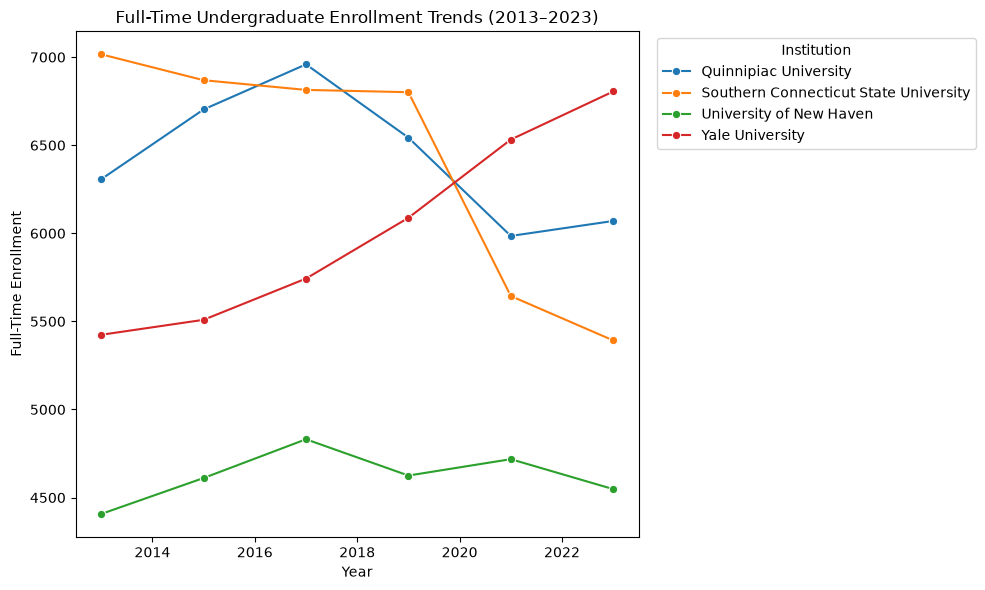

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=df, x="year", y="enroll_ft", hue="institution", marker="o", ax=ax)

ax.set_title("Full-Time Undergraduate Enrollment Trends (2013–2023)")
ax.set_xlabel("Year")
ax.set_ylabel("Full-Time Enrollment")

ax.legend(title="Institution", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "01_enrollment_trends.png", dpi=300, bbox_inches="tight")
plt.show()

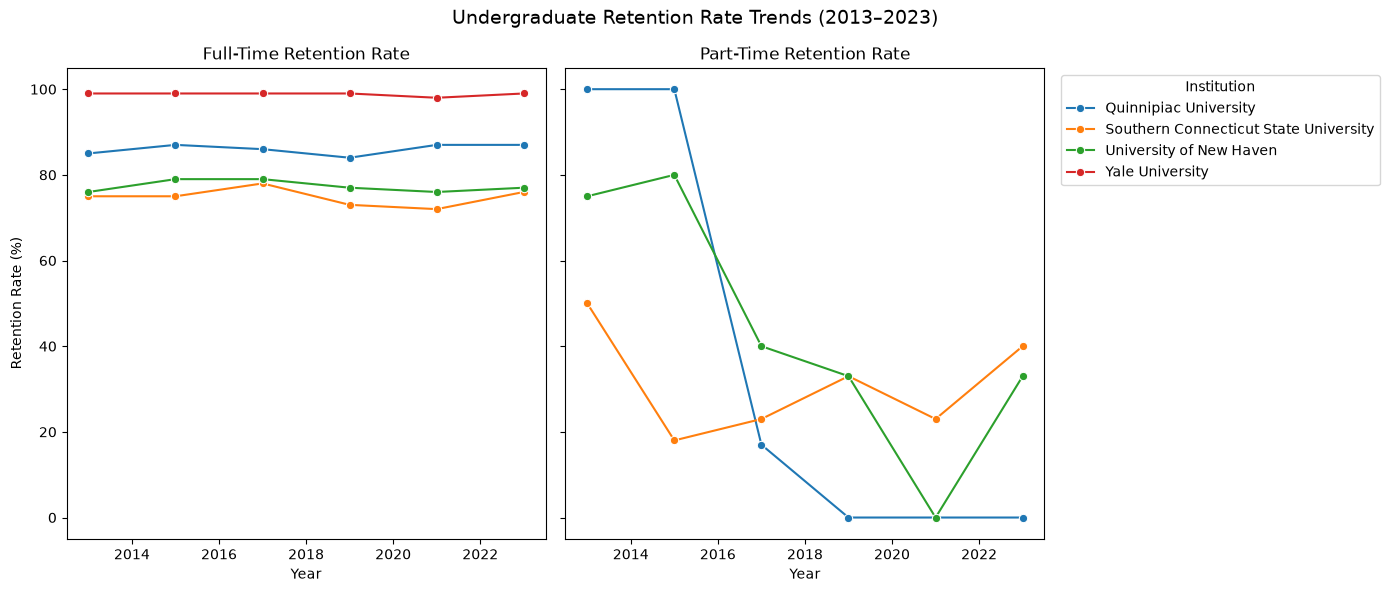

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.lineplot(data=df, x="year", y="retention_ft", hue="institution", marker="o", ax=axes[0], legend=False)
sns.lineplot(data=df, x="year", y="retention_pt", hue="institution", marker="o", ax=axes[1])

axes[0].set_title("Full-Time Retention Rate")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Retention Rate (%)")

axes[1].set_title("Part-Time Retention Rate")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("")

axes[1].legend(title="Institution", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.suptitle("Undergraduate Retention Rate Trends (2013–2023)", fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "02_retention_trends.png", dpi=300, bbox_inches="tight")
plt.show()

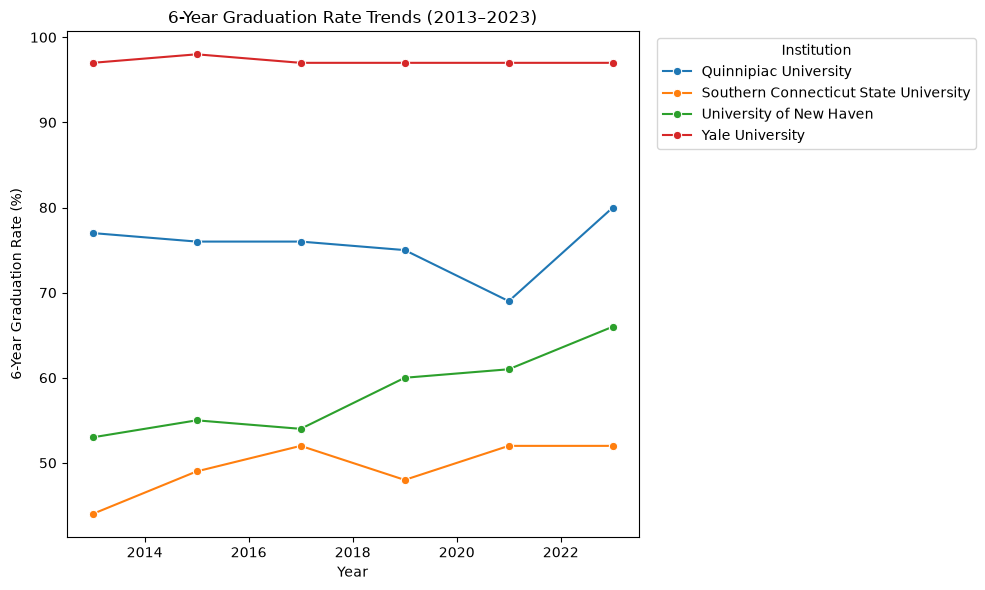

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=df, x="year", y="grad_rate_6yr", hue="institution", marker="o", ax=ax)

ax.set_title("6-Year Graduation Rate Trends (2013–2023)")
ax.set_xlabel("Year")
ax.set_ylabel("6-Year Graduation Rate (%)")

ax.legend(title="Institution", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "03_graduation_trends.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
df_2023 = df[df["year"] == 2023].set_index("institution")

metrics = ["grad_rate_4yr", "grad_rate_6yr", "retention_ft", "retention_pt"]
df_2023_subset = df_2023[metrics]

df_2023_subset

,grad_rate_4yr,grad_rate_6yr,retention_ft,retention_pt
institution,,,,
Quinnipiac University,77,80,87,0.0
Southern Connecticut State University,29,52,76,40.0
University of New Haven,52,66,77,33.0
Yale University,88,97,99,NaN


df[df["year"] == 2023]：跟之前筛Yale那次一样的布尔筛选写法，这次筛的是"year这一列等于2023"的所有行——4所学校每人一行。

.set_index("institution")：把institution这一列设为索引（index）。为什么要这样做：等会儿画柱状图时，pandas的.plot(kind="bar")默认会把索引当成x轴的分类标签。如果不设置index，x轴会显示无意义的0,1,2,3行号，而不是学校名字。

metrics = [...]：只挑这次要画的4个指标（4yr grad、6yr grad、FT retention、PT retention），先跳过enrollment（人数规模和百分比指标数值差异太大，放一张图里会因为y轴尺度问题看不清）。

df_2023_subset：最后打印出来，让你先看清楚这个"准备好要画图"的小表长什么样——4行（学校）× 4列（指标），这是画分组柱状图最理想的数据形状。

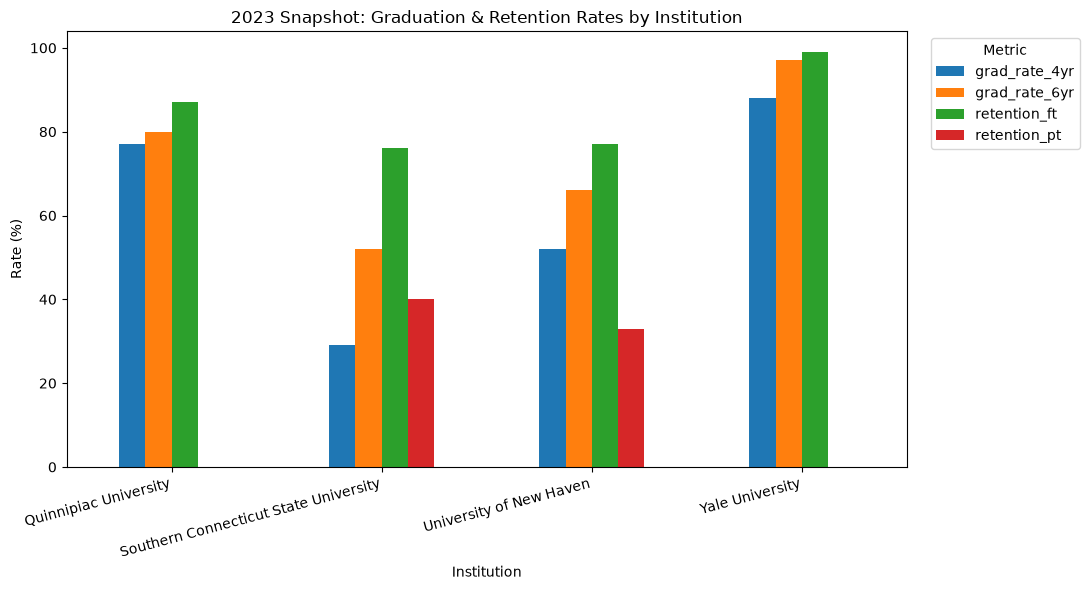

In [21]:
fig, ax = plt.subplots(figsize=(11, 6))

df_2023_subset.plot(kind="bar", ax=ax)

ax.set_title("2023 Snapshot: Graduation & Retention Rates by Institution")
ax.set_xlabel("Institution")
ax.set_ylabel("Rate (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")

ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "04_2023_snapshot.png", dpi=300, bbox_inches="tight")
plt.show()